# Objective
**Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.**

# Part A - Data Loading and Preprocessing with Scikit-learn

**Task 1 - Load and Understand the Dataset**
* Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.
* Check the class distribution of is_canceled and use it as the target y.
* Create X from the remaining usable features. Identify numerical and categorical columns.

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('hotel_bookings.csv')
print(data.head(5))
print(data.shape)
print(data.info())
print(data.describe())
print(data.dtypes)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [3]:
# class distribution of is_cancelled
print("\nClass Distribution:")
print(data["is_canceled"].value_counts())


Class Distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [4]:
# Target variable
y = data["is_canceled"]

# Remaining columns are input features
X = data.drop(columns=["is_canceled"])

In [5]:
# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\devan\AppData\Local\Temp\ipykernel_19656\2736801362.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


**Task 2 - Missing Values, Leakage, and Outliers**
* Find the missing-value count and percentage for every column.
* Identify columns with very high missingness. Drop them only if justified and state the reason.
* Remove columns that directly reveal the final booking outcome, such as reservation_status and
reservation_status_date.
* Check selected numerical features for outliers using boxplots and/or the IQR method.
* Remove only clear/extreme outliers and report how many rows were removed.

In [6]:
# Missing value count
missing_count = data.isnull().sum()

print("\nMissing Values:")
print(missing_count)

# Missing value percentage
missing_percentage = (data.isnull().sum() / len(data)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Values:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340

- children has 4 missing values, it is not very high so we don't need to remove it
- country has 488 missing values, it is higher than children but decision has to be made that we should remove it not based on its influence on other columns
- agent column has 16340 missing value, it is very much higher we need to remove this column because, it will not contribute anyway in model and only increase the computation. so we remove this column
- similar for company

In [7]:
df = data.drop(columns=["company", "agent"])

In [8]:
df = df.drop(columns=["reservation_status", "reservation_status_date"])

reservation status tells us whether booking is cancelled or not, if this is kept in data then classification model will get data and it will connect it directly to the output

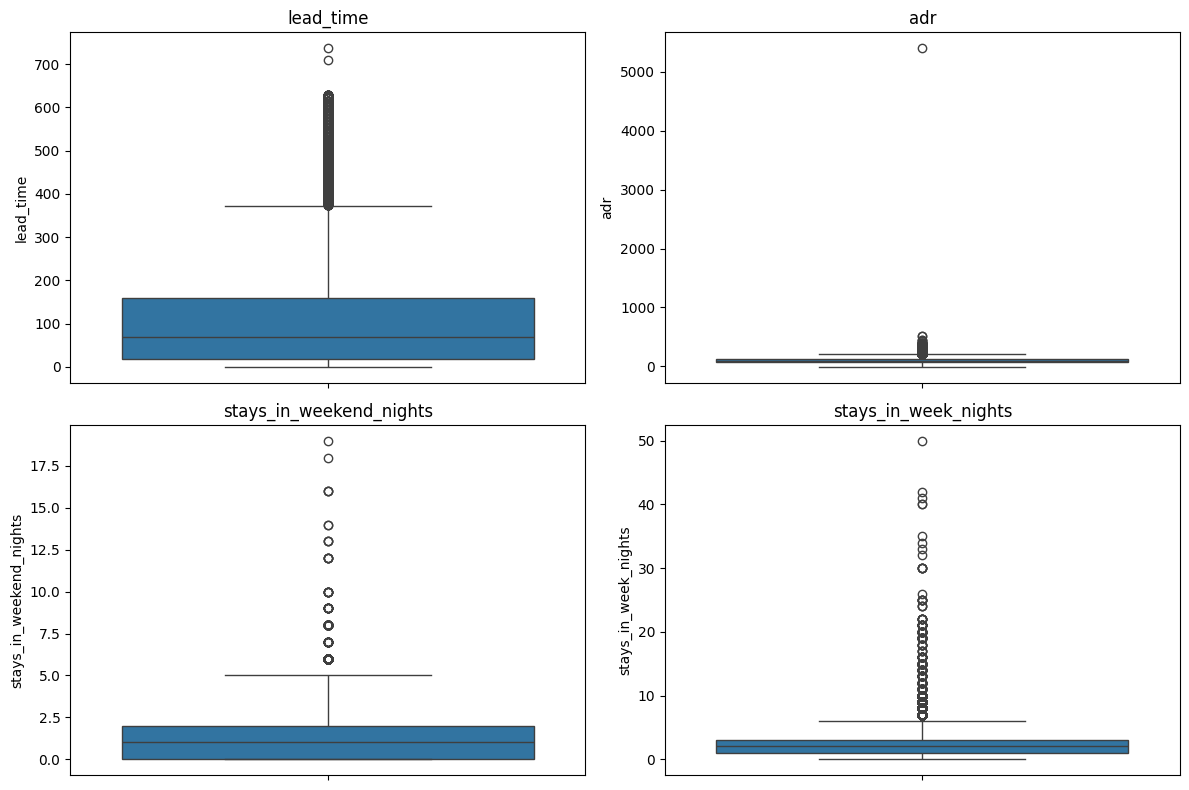

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select some numerical columns
outlier_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]

# Create boxplots
plt.figure(figsize=(12, 8))

for i, column in enumerate(outlier_columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

- What does lead_time mean?
- It is the number of days between: booking date → arrival date
- For example: A customer books a hotel 100 days before arriving → lead_time = 100.
- Some values are around 700+ days, which are unusually high compared with most bookings.
- Most bookings are made relatively close to the arrival date, but some bookings are made much earlier and appear as potential outliers.

- What does adr mean? ADR = Average Daily Rate
- It represents the average price per room per day.
- For example: ADR = 100 means approximately £100 per room per day.
- This graph has a very large outlier around 5400.
- Most values are concentrated near the bottom, while one or a few values are extremely high.
- This is why the box looks very compressed.
- The majority of ADR values are much smaller than the extreme value.
- So this column clearly deserves an outlier check.
- ADR contains extreme high values, with one value around 5400 that is far above the normal range.

- Most customers stay between approximately:
- 0–2 weekend nights
- The median is around 1 night.
- The upper whisker reaches approximately 5 nights.

- Most bookings have approximately 1–3 weekday nights.
- The median is around 2 nights.
- The upper whisker is around 6 nights.
- Most customers stay only a few weekday nights, but some bookings have unusually long stays.

The box plots show that all four numerical features contain potential outliers. Lead time has several unusually high booking periods, ADR contains an extreme high value, and both weekend and weekday stay durations have some unusually long stays. These outliers were therefore checked using the IQR method before preprocessing.

In [10]:
# IQR method for ADR
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nADR Outlier Information:")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Count ADR outliers
adr_outliers = df[
    (df["adr"] < lower_bound) |
    (df["adr"] > upper_bound)
]

print("ADR outliers:", len(adr_outliers))

rows_before = len(df)

df = df[
    (df["adr"] >= 0) &
    (df["adr"] <= upper_bound)
]

rows_after = len(df)

print("Rows removed:", rows_before - rows_after)


ADR Outlier Information:
Q1: 69.29
Q3: 126.0
IQR: 56.709999999999994
Lower Bound: -15.774999999999991
Upper Bound: 211.065
ADR outliers: 3793
Rows removed: 3794


**Task 3 - Create Two Preprocessing Pipelines**
* Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for
all experiments.
* For numerical columns, use KNNImputer(n_neighbors=5) for missing values.
* For categorical columns, use SimpleImputer(strategy="most_frequent") and
OneHotEncoder(handle_unknown="ignore").
* Pipeline A: KNNImputer + StandardScaler for numerical features.
* Pipeline B: KNNImputer + MinMaxScaler for numerical features.
* Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [20]:
print(df.columns)
# Target variable

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()
print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)
y = df["is_canceled"]

# Remaining columns are input features
X = df.drop(columns=["is_canceled"])

print(y.head(1),X.head(1))


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')
Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'tota

C:\Users\devan\AppData\Local\Temp\ipykernel_19656\1563827679.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 92476
Testing rows: 23120


In [23]:
# for numerical
# Pipeline A:
# Missing values -> KNN Imputer
# Scaling -> StandardScaler

numerical_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])


# Pipeline B:
# Missing values -> KNN Imputer
# Scaling -> MinMaxScaler

numerical_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])


In [24]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
# Preprocessor for Pipeline A
preprocessor_A = ColumnTransformer([
    ("numerical", numerical_pipeline_A, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])


# Preprocessor for Pipeline B
preprocessor_B = ColumnTransformer([
    ("numerical", numerical_pipeline_B, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

# Part B - Model Training and Performance Evaluation

**Task 4 - Train Two Classification Models**
* Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.
* Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.
* Keep the model settings and train-test split unchanged across the comparison.
* You should obtain four trained model-pipeline combinations in total.

In [26]:
# Logistic Regression + StandardScaler
logistic_A = Pipeline([
    ("preprocessing", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])


# Logistic Regression + MinMaxScaler
logistic_B = Pipeline([
    ("preprocessing", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])


# Decision Tree + StandardScaler
tree_A = Pipeline([
    ("preprocessing", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])


# Decision Tree + MinMaxScaler
tree_B = Pipeline([
    ("preprocessing", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [27]:
logistic_A.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [28]:
logistic_B.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [29]:
tree_A.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [30]:
tree_B.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [31]:
# Logistic Regression + StandardScaler
train_pred_logistic_A = logistic_A.predict(X_train)
test_pred_logistic_A = logistic_A.predict(X_test)

# Logistic Regression + MinMaxScaler
train_pred_logistic_B = logistic_B.predict(X_train)
test_pred_logistic_B = logistic_B.predict(X_test)

# Decision Tree + StandardScaler
train_pred_tree_A = tree_A.predict(X_train)
test_pred_tree_A = tree_A.predict(X_test)

# Decision Tree + MinMaxScaler
train_pred_tree_B = tree_B.predict(X_train)
test_pred_tree_B = tree_B.predict(X_test)

In [32]:
# Logistic Regression + StandardScaler
logistic_A_train_accuracy = accuracy_score(
    y_train, train_pred_logistic_A
)

logistic_A_test_accuracy = accuracy_score(
    y_test, test_pred_logistic_A
)

logistic_A_precision = precision_score(
    y_test, test_pred_logistic_A
)

logistic_A_recall = recall_score(
    y_test, test_pred_logistic_A
)

logistic_A_f1 = f1_score(
    y_test, test_pred_logistic_A
)

In [33]:
# Logistic Regression + MinMaxScaler
logistic_B_train_accuracy = accuracy_score(
    y_train, train_pred_logistic_B
)

logistic_B_test_accuracy = accuracy_score(
    y_test, test_pred_logistic_B
)

logistic_B_precision = precision_score(
    y_test, test_pred_logistic_B
)

logistic_B_recall = recall_score(
    y_test, test_pred_logistic_B
)

logistic_B_f1 = f1_score(
    y_test, test_pred_logistic_B
)


In [34]:
# Decision Tree + StandardScaler
tree_A_train_accuracy = accuracy_score(
    y_train, train_pred_tree_A
)

tree_A_test_accuracy = accuracy_score(
    y_test, test_pred_tree_A
)

tree_A_precision = precision_score(
    y_test, test_pred_tree_A
)

tree_A_recall = recall_score(
    y_test, test_pred_tree_A
)

tree_A_f1 = f1_score(
    y_test, test_pred_tree_A
)

In [35]:
# Decision Tree + MinMaxScaler
tree_B_train_accuracy = accuracy_score(
    y_train, train_pred_tree_B
)

tree_B_test_accuracy = accuracy_score(
    y_test, test_pred_tree_B
)

tree_B_precision = precision_score(
    y_test, test_pred_tree_B
)

tree_B_recall = recall_score(
    y_test, test_pred_tree_B
)

tree_B_f1 = f1_score(
    y_test, test_pred_tree_B
)


In [36]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Decision Tree",
        "Decision Tree"
    ],

    "Preprocessing": [
        "StandardScaler",
        "MinMaxScaler",
        "StandardScaler",
        "MinMaxScaler"
    ],

    "Training Accuracy": [
        logistic_A_train_accuracy,
        logistic_B_train_accuracy,
        tree_A_train_accuracy,
        tree_B_train_accuracy
    ],

    "Testing Accuracy": [
        logistic_A_test_accuracy,
        logistic_B_test_accuracy,
        tree_A_test_accuracy,
        tree_B_test_accuracy
    ],

    "Precision": [
        logistic_A_precision,
        logistic_B_precision,
        tree_A_precision,
        tree_B_precision
    ],

    "Recall": [
        logistic_A_recall,
        logistic_B_recall,
        tree_A_recall,
        tree_B_recall
    ],

    "F1 Score": [
        logistic_A_f1,
        logistic_B_f1,
        tree_A_f1,
        tree_B_f1
    ]
})


print("\nFinal Model Comparison:")
print(results)


# Round the values for easier reading
print("\nRounded Results:")
print(results.round(4))


Final Model Comparison:
                 Model   Preprocessing  Training Accuracy  Testing Accuracy  \
0  Logistic Regression  StandardScaler           0.820613          0.817950   
1  Logistic Regression    MinMaxScaler           0.817066          0.814403   
2        Decision Tree  StandardScaler           0.996021          0.855190   
3        Decision Tree    MinMaxScaler           0.996021          0.855017   

   Precision    Recall  F1 Score  
0   0.812464  0.660157  0.728434  
1   0.810586  0.650099  0.721526  
2   0.800162  0.811016  0.805552  
3   0.799447  0.811601  0.805478  

Rounded Results:
                 Model   Preprocessing  Training Accuracy  Testing Accuracy  \
0  Logistic Regression  StandardScaler             0.8206            0.8179   
1  Logistic Regression    MinMaxScaler             0.8171            0.8144   
2        Decision Tree  StandardScaler             0.9960            0.8552   
3        Decision Tree    MinMaxScaler             0.9960            0

In [37]:
best_logistic_index = results[
    results["Model"] == "Logistic Regression"
]["F1 Score"].idxmax()

print("\nBest Logistic Regression:")
print(results.loc[best_logistic_index])


Best Logistic Regression:
Model                Logistic Regression
Preprocessing             StandardScaler
Training Accuracy               0.820613
Testing Accuracy                 0.81795
Precision                       0.812464
Recall                          0.660157
F1 Score                        0.728434
Name: 0, dtype: object


In [38]:
best_tree_index = results[
    results["Model"] == "Decision Tree"
]["F1 Score"].idxmax()

print("\nBest Decision Tree:")
print(results.loc[best_tree_index])


Best Decision Tree:
Model                 Decision Tree
Preprocessing        StandardScaler
Training Accuracy          0.996021
Testing Accuracy            0.85519
Precision                  0.800162
Recall                     0.811016
F1 Score                   0.805552
Name: 2, dtype: object


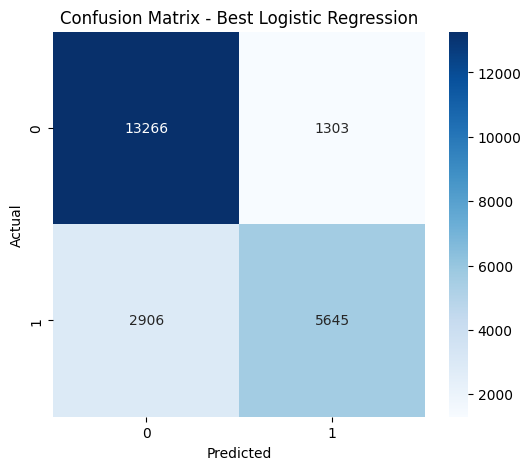

In [39]:
if best_logistic_index == 0:
    best_logistic_predictions = test_pred_logistic_A
else:
    best_logistic_predictions = test_pred_logistic_B


cm_logistic = confusion_matrix(
    y_test,
    best_logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



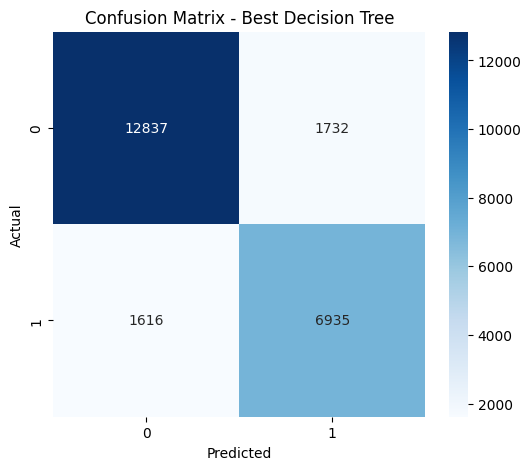

In [ ]:
if best_tree_index == 2:
    best_tree_predictions = test_pred_tree_A
else:
    best_tree_predictions = test_pred_tree_B


cm_tree = confusion_matrix(
    y_test,
    best_tree_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [ ]:
results["Accuracy Difference"] = (
    results["Training Accuracy"] -
    results["Testing Accuracy"]
)

print("\nTraining vs Testing Accuracy Difference:")
print(
    results[
        [
            "Model",
            "Preprocessing",
            "Accuracy Difference"
        ]
    ].round(4)
)



Training vs Testing Accuracy Difference:
                 Model   Preprocessing  Accuracy Difference
0  Logistic Regression  StandardScaler               0.0027
1  Logistic Regression    MinMaxScaler               0.0027
2        Decision Tree  StandardScaler               0.1408
3        Decision Tree    MinMaxScaler               0.1410


In [42]:
best_overall_index = results["F1 Score"].idxmax()

print("\nBest Overall Model:")
print(results.loc[best_overall_index])




Best Overall Model:
Model                   Decision Tree
Preprocessing          StandardScaler
Training Accuracy            0.996021
Testing Accuracy              0.85519
Precision                    0.800162
Recall                       0.811016
F1 Score                     0.805552
Accuracy Difference           0.14083
Name: 2, dtype: object


- The model with the highest F1 score gives the best overall classification performance."
- Logistic Regression can be affected by the choice of scaling because it uses numerical feature values during optimization.
- Decision Trees generally do not depend strongly on feature scaling because they split data based on feature thresholds."
- A large difference between training and testing accuracy can indicate possible overfitting."
- The confusion matrices show the number of correct and incorrect predictions for cancelled and non-cancelled bookings."